In [60]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from fredapi import Fred
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

SP500 = pd.read_csv("data/raw/SP500_prices.csv", index_col = 0,parse_dates=True)
VIX = pd.read_csv("data/raw/VIX_prices.csv", index_col = 0,parse_dates=True)
rates = pd.read_csv("data/raw/Global_Rate.csv", index_col = 0,parse_dates=True)
SP500_index = yf.download("^GSPC", start = "2014-01-01", end ="2024-12-31",auto_adjust=False)
Dividends = pd.read_csv("data/raw/SP500_dividends.csv",index_col=0,parse_dates=True)
shares = pd.read_csv("data/raw/SP500_shares.csv",index_col=0,parse_dates=True)
SP500_index_monthly = SP500_index["Adj Close"].resample("ME").last().squeeze()
SP500_monthly = SP500.resample("ME").last()

print(SP500.shape)
print(VIX.shape)
print(rates.shape)

rates_aligned = rates.reindex(SP500.index)
rates_aligned = rates_aligned.fillna(method="ffill")
print(rates_aligned.shape)



[*********************100%***********************]  1 of 1 completed

(2767, 503)
(2767, 1)
(2870, 3)
(2767, 3)



C:\Users\anton\AppData\Local\Temp\ipykernel_30632\108663177.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rates_aligned = rates_aligned.fillna(method="ffill")


In [61]:

def compute_return (prices, n_month) :
    past_prices = prices.shift(n_month)

    rendement = (prices - past_prices)/ past_prices

    return rendement

return_1m = compute_return(SP500_monthly,1)
return_3m = compute_return(SP500_monthly,3)
return_6m = compute_return(SP500_monthly,6)
return_12m = compute_return(SP500_monthly,12)

SP500_return_1m = compute_return(SP500_index_monthly,1)
SP500_return_3m = compute_return(SP500_index_monthly,3)
SP500_return_6m = compute_return(SP500_index_monthly,6)
SP500_return_12m = compute_return(SP500_index_monthly,12)

return_1m_vs_SP500_return_1m   = return_1m.sub(SP500_return_1m,   axis=0)
return_3m_vs_SP500_return_3m   = return_3m.sub(SP500_return_3m,   axis=0)
return_6m_vs_SP500_return_6m   = return_6m.sub(SP500_return_6m,   axis=0)
return_12m_vs_SP500_return_12m = return_12m.sub(SP500_return_12m, axis=0)


print(return_1m.shape)
print(return_12m.head(15))

print(SP500_index_monthly.shape)   # (132,)
print(SP500_index_monthly.head(3))

print(return_1m_vs_SP500_return_1m.shape)
print(return_1m_vs_SP500_return_1m.head(14))



(132, 503)
                   A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2014-01-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-02-28       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-03-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-04-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-05-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-06-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-07-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-08-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-09-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-10-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-11-30       NaN       Na

In [62]:


def compute_volatility (prices, n_month):
    r = prices.pct_change()

    def std_manuel (df) : 
        r_moyen = df.mean()
        n = len(df)
        std = np.sqrt((1/(n-1))*np.sum((df-r_moyen)**2))

        return std*np.sqrt(252)
    
    vol_by_month = r.resample("ME").apply(std_manuel)

    vol = vol_by_month.rolling(n_month).mean()
    
                
    return vol

vol_1m = compute_volatility(SP500, 1)
vol_3m = compute_volatility(SP500, 3)
vol_6m = compute_volatility(SP500, 6)

print(vol_1m.shape)
print(vol_1m.head(3))
print(vol_1m.describe())

C:\Users\anton\AppData\Local\Temp\ipykernel_30632\3830648658.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r = prices.pct_change()


(132, 503)
                   A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2014-01-31  0.224611  0.338094  0.236241   0.0  0.188742  0.141429  0.216019   
2014-02-28  0.388356  0.175838  0.213990   0.0  0.142586  0.145460  0.154104   
2014-03-31  0.194122  0.108769  0.226133   0.0  0.136993  0.127743  0.241575   

                ADBE       ADI       ADM  ...        WY      WYNN       XEL  \
Date                                      ...                                 
2014-01-31  0.233206  0.167303  0.244666  ...  0.166947  0.443128  0.131391   
2014-02-28  0.251259  0.135517  0.168175  ...  0.131675  0.287759  0.103484   
2014-03-31  0.213056  0.176552  0.160119  ...  0.140203  0.236672  0.130850   

                 XOM       XYL  XYZ       YUM       ZBH      ZBRA       ZTS  
Date                                                                         
2014-01-31  0.148962  0.264531  0.0 

In [63]:
## calcule du beta pour chaque action par rapport au SP500

def beta(prices, sp500_index, n_months) :

    r_action = prices.pct_change(fill_method=None)

    r_sp500_index = sp500_index.pct_change(fill_method=None)

    combined = r_action.copy()
    combined["SP500"] = r_sp500_index

    def beta_monthly (r_combined) :

        df_action = r_combined.drop(columns="SP500")
        df_sp500 = r_combined["SP500"]
        n = len(df_action)

        cov = (1/(n-1)) * np.sum((df_action - df_action.mean()).multiply(df_sp500 - df_sp500.mean(), axis=0), axis=0)
        var = (1/(n-1)) * np.sum((df_sp500 - df_sp500.mean())**2)

        return cov/var


    beta_by_month = combined.resample("ME").apply(beta_monthly)
    beta= beta_by_month.rolling(n_months).mean()

    return beta

beta_12m = beta(SP500, SP500_index["Adj Close"], 12)

print(beta_12m.shape)
print(beta_12m.describe())


(132, 503)
                A        AAPL        ABBV        ABNB         ABT        ACGL  \
count  121.000000  121.000000  121.000000  121.000000  121.000000  121.000000   
mean     1.135019    1.211583    0.791269    0.522428    0.834061    0.663117   
std      0.200057    0.181343    0.426706    0.739746    0.281228    0.264654   
min      0.776559    0.745037    0.063043   -0.078065    0.123857    0.114101   
25%      0.927235    1.089756    0.427827    0.000000    0.628487    0.485578   
50%      1.161559    1.240645    0.855358    0.000000    0.882533    0.604958   
75%      1.284470    1.356221    1.104284    1.433527    1.053762    0.834992   
max      1.545748    1.485995    1.544499    1.854848    1.271020    1.308717   

              ACN        ADBE         ADI         ADM  ...          WY  \
count  121.000000  121.000000  121.000000  121.000000  ...  121.000000   
mean     1.025298    1.308213    1.346122    0.788378  ...    1.013609   
std      0.122518    0.200782    0.16

In [64]:
## calcule du max drawdown mensuelle pour chaque action

def max_drawdown(prices, n_months) :

    prices_monthly = prices.resample("ME").last()

    def mdd (df) :
        peak = df.max()
        peak_idx = df.idxmax()

        trought = df.loc[peak_idx:].min()
        return (trought - peak)/peak
    
    

    max_dd = prices_monthly.rolling(n_months).apply(mdd, raw=False)

    return max_dd


mdd_3m = max_drawdown(SP500, 3)

print(mdd_3m.shape)
print(mdd_3m.describe())
print(mdd_3m.head(5))

(132, 503)
                A        AAPL        ABBV       ABNB         ABT        ACGL  \
count  130.000000  130.000000  130.000000  47.000000  130.000000  130.000000   
mean    -0.038277   -0.038401   -0.038307  -0.083065   -0.030220   -0.030419   
std      0.047684    0.055411    0.051451   0.096409    0.041829    0.057534   
min     -0.182388   -0.276751   -0.222826  -0.418576   -0.206550   -0.405639   
25%     -0.067882   -0.068668   -0.072142  -0.135620   -0.054025   -0.042748   
50%     -0.014881    0.000000   -0.001998  -0.059619   -0.003387    0.000000   
75%      0.000000    0.000000    0.000000   0.000000    0.000000    0.000000   
max      0.000000    0.000000    0.000000   0.000000    0.000000    0.000000   

              ACN        ADBE         ADI         ADM  ...          WY  \
count  130.000000  130.000000  130.000000  130.000000  ...  130.000000   
mean    -0.031976   -0.044295   -0.035693   -0.042295  ...   -0.051351   
std      0.050158    0.061582    0.046076    0

In [65]:
##features macroeconomiques : vix mensuelle, taux d'interet mensuel

VIX_monthly = VIX.resample("ME").last()
rates_monthly = rates.resample("ME").last()


print(VIX_monthly.shape)      # (132, 1)
print(rates_monthly.shape)    # (132, 3)
print(SP500_return_1m.shape)  # (132,) ou (132, 1)

(132, 1)
(132, 3)
(132,)


In [66]:
## features technique prix comparer a la moyenne du prix sur les X derniers jours

def prix_vs_ma (prices, n_days) :

    ma_ndays = prices.rolling(n_days).mean()

    ratio = prices/ma_ndays

    prix_vs_ma_monthly = ratio.resample("ME").last()

    return prix_vs_ma_monthly

price_vs_ma50  = prix_vs_ma(SP500, 50)
price_vs_ma200 = prix_vs_ma(SP500, 200)

print(price_vs_ma50.shape)
print(price_vs_ma50.describe())

print(price_vs_ma200.shape)
print(price_vs_ma200.describe())

# Valeurs attendues :
# moyenne ≈ 1.0
# > 1 → marché haussier
# < 1 → marché baissier

(132, 503)
                A        AAPL        ABBV       ABNB         ABT        ACGL  \
count  130.000000  130.000000  130.000000  47.000000  130.000000  130.000000   
mean     1.011788    1.024289    1.013381   0.996637    1.013190    1.015452   
std      0.058784    0.068390    0.063126   0.092725    0.049701    0.059319   
min      0.873341    0.848054    0.845660   0.735519    0.866381    0.715629   
25%      0.972411    0.979342    0.970150   0.938390    0.982629    0.989946   
50%      1.011133    1.029200    1.016060   0.996336    1.015723    1.021529   
75%      1.055048    1.067394    1.056097   1.054440    1.046521    1.039976   
max      1.150639    1.242523    1.157542   1.189677    1.126999    1.222276   

              ACN        ADBE         ADI         ADM  ...          WY  \
count  130.000000  130.000000  130.000000  130.000000  ...  130.000000   
mean     1.015642    1.020756    1.017378    1.006611  ...    1.005999   
std      0.053901    0.069481    0.058324    0

In [67]:
## calcule du volume ratio qui veaut le volume moyen de ce mois/ volume moyen des trois dernier mois 

Volume = pd.read_csv("data/raw/SP500_volume.csv",index_col=0,parse_dates=True)
print(Volume.shape)

def volume_ratio (volume, n_months) :

    vol_monthly = volume.resample("ME").mean()

    vol_rolling = vol_monthly.rolling(n_months).mean().shift(1)

    ratio = vol_monthly/vol_rolling

    return ratio

volume_ratioo = volume_ratio(Volume, 3)

print(volume_ratioo.head(5))




(2767, 503)
                   A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2014-01-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-02-28       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-03-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2014-04-30  0.693773  0.952542  1.107412   NaN  0.895944  0.854406  1.123079   
2014-05-31  0.797385  0.959350  0.675817   NaN  0.647870  0.746091  0.659275   

                ADBE       ADI       ADM  ...        WY      WYNN       XEL  \
Date                                      ...                                 
2014-01-31       NaN       NaN       NaN  ...       NaN       NaN       NaN   
2014-02-28       NaN       NaN       NaN  ...       NaN       NaN       NaN   
2014-03-31       NaN       NaN       NaN  ...       NaN       NaN       NaN   
2014-04-30  1.124092  0.860759  

In [68]:
## construction du RSI 14 jours

def rsi(prices, n_days) :

    delta = prices.diff()

    gain = delta[delta>0].fillna(0)
    losses = delta[delta<0].fillna(0)

    avg_gain = gain.rolling(n_days).mean()
    avg_losses = losses.rolling(n_days).mean()

    rs = avg_gain/(-avg_losses)

    rsi = 100-(100/(1+rs))

    rsi_monthly = rsi.resample("ME").last()

    return rsi_monthly

rsi_14 = rsi(SP500, 14)

print(rsi_14.shape)
print(rsi_14.describe())
print(rsi_14.head(5))

(132, 503)
                A        AAPL        ABBV       ABNB         ABT        ACGL  \
count  132.000000  132.000000  132.000000  49.000000  132.000000  132.000000   
mean    52.130641   55.139821   52.325257  51.044415   53.974388   54.298923   
std     17.610412   18.125374   17.242000  12.683840   18.043564   16.276483   
min     12.148705    4.784342   13.828516  29.090930    6.280573    9.259255   
25%     39.034232   42.365965   40.958558  43.011973   40.501800   43.643205   
50%     53.061977   54.218479   52.875778  50.977442   55.495281   54.560857   
75%     66.473533   68.951929   64.396423  58.284672   66.584336   64.804368   
max     89.827551   95.124082   89.046677  78.054402   90.200787   97.249995   

              ACN        ADBE         ADI         ADM  ...          WY  \
count  132.000000  132.000000  132.000000  132.000000  ...  132.000000   
mean    55.685934   55.623065   53.633704   52.313945  ...   51.041587   
std     18.418678   18.086247   16.325338   16

In [69]:
## MACD signal

def ema(prices, n_days) :

        alpha = 2/(n_days +1)

        ema_df = prices.copy()

        for i in range (1,len(prices)) :

            ema_df.iloc[i] = prices.iloc[i]*alpha + ema_df.iloc[i-1]*(1-alpha)

        return ema_df

def macd_signal(prices) :

    ema_12 = ema(prices,12)
    ema_26 = ema(prices,26)
    macd = ema_12-ema_26
    signal = ema(macd,9)
    macd_sig = macd - signal

    macd_signal_monthly = macd_sig.resample("ME").last()

    return macd_signal_monthly

macd_monthly = macd_signal(SP500)
print(macd_monthly.shape)
print(macd_monthly.head(3))
    



(132, 503)
                   A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2014-01-31 -0.156590 -0.168192 -0.045755   NaN -0.231700 -0.013132 -0.360717   
2014-02-28 -0.069396 -0.002762  0.071255   NaN  0.166689  0.075487  0.195941   
2014-03-31 -0.057205  0.019707 -0.123277   NaN -0.121070 -0.041184 -0.400269   

                ADBE       ADI       ADM  ...        WY      WYNN       XEL  \
Date                                      ...                                 
2014-01-31 -0.184761 -0.108518 -0.148730  ... -0.040936 -0.015556  0.031981   
2014-02-28  0.178737  0.083967  0.096222  ... -0.007741  1.455296  0.032219   
2014-03-31 -0.502767  0.036522  0.028704  ... -0.006274 -2.122576 -0.012080   

                 XOM       XYL  XYZ       YUM       ZBH      ZBRA       ZTS  
Date                                                                         
2014-01-31 -0.361211 -0.260871  NaN 

In [70]:
## calcul du rendement des dividendes sur 12 mois
def dividend_yeld (dividends, prices_monthly):
    div_monthly = dividends.resample("ME").sum()

    div_12m = div_monthly.rolling(12).sum()

    dividends_yelds = div_12m/prices_monthly

    return dividends_yelds


print(Dividends.shape)
print(Dividends.head(3))
print(Dividends["AAPL"].dropna().head(5))

dividend_yield = dividend_yeld(Dividends, SP500_monthly)

print(dividend_yield.shape)
print(dividend_yield.describe())


(2553, 503)
                 MMM  AOS  ABT  ABBV  ACN  ADBE  AMD  AES    AFL   A  ...  \
2014-02-12  0.714883  NaN  NaN   NaN  NaN   NaN  NaN  NaN  0.185 NaN  ...   
2014-05-21  0.714883  NaN  NaN   NaN  NaN   NaN  NaN  NaN    NaN NaN  ...   
2014-08-20  0.714883  NaN  NaN   NaN  NaN   NaN  NaN  NaN    NaN NaN  ...   

            WMB  WTW  WDAY  WYNN  XEL  XYL  YUM  ZBRA  ZBH  ZTS  
2014-02-12  NaN  NaN   NaN   NaN  NaN  NaN  NaN   NaN  NaN  NaN  
2014-05-21  NaN  NaN   NaN   NaN  NaN  NaN  NaN   NaN  NaN  NaN  
2014-08-20  NaN  NaN   NaN   NaN  NaN  NaN  NaN   NaN  NaN  NaN  

[3 rows x 503 columns]
2014-02-06    0.108929
2014-11-06    0.117500
2015-08-06    0.130000
2018-11-08    0.182500
2019-11-07    0.192500
Name: AAPL, dtype: float64
(132, 503)
                A        AAPL        ABBV  ABNB         ABT        ACGL  \
count  121.000000  121.000000  121.000000  49.0  121.000000  121.000000   
mean     0.008263    0.011916    0.050184   0.0    0.020508    0.000860   
std      0.00

In [71]:
## calcule la market cap de chaque action

def market_cap(prices,shares):

    share_daily = shares.reindex(prices.index).ffill() ## Réindex shares sur les meme dates que prices et propage les valeurs
    market_cap = prices*share_daily

    market_cap_monthly = market_cap.resample("ME").last()

    return market_cap_monthly

market_cap_monthly = market_cap(SP500, shares)
print(market_cap_monthly.shape)
print(market_cap_monthly.describe())

(132, 503)
                  A          AAPL          ABBV          ABNB           ABT  \
count  1.120000e+02  1.110000e+02  1.100000e+02  4.900000e+01  1.100000e+02   
mean   2.820837e+10  1.324390e+12  1.539487e+11  8.808254e+10  1.371498e+11   
std    1.090695e+10  1.247414e+12  8.029752e+10  1.559337e+10  5.304466e+10   
min    1.045199e+10  1.177130e+11  5.819695e+10  5.413664e+10  4.682577e+10   
25%    1.991566e+10  1.990115e+11  8.675131e+10  7.547895e+10  9.058415e+10   
50%    2.567124e+10  3.338757e+11  1.241450e+11  8.755151e+10  1.490469e+11   
75%    3.793478e+10  2.578230e+12  2.289326e+11  9.891897e+10  1.818722e+11   
max    5.148737e+10  3.791493e+12  3.451607e+11  1.232834e+11  2.297278e+11   

               ACGL           ACN          ADBE           ADI           ADM  \
count  1.100000e+02  1.090000e+02  1.120000e+02  1.090000e+02  1.100000e+02   
mean   1.556129e+10  1.338552e+11  1.601360e+11  5.324999e+10  2.590074e+10   
std    9.635787e+09  5.778466e+10  7.723

In [72]:
## assemblage de toutes les features en un seul dataset

def stack_features(df, name) :

    s = df.stack()
    s.index.names = ["Date", "Ticker"]
    s.name = name

    return s


features_list = [stack_features(return_1m,"return_1m"),
    stack_features(return_3m,"return_3m"),
    stack_features(return_6m,"return_6m"),
    stack_features(return_12m,"return_12m"),
    stack_features(return_1m_vs_SP500_return_1m,"return_1m_vs_SP500"),
    stack_features(return_3m_vs_SP500_return_3m,"return_3m_vs_SP500"),
    stack_features(return_6m_vs_SP500_return_6m,"return_6m_vs_SP500"),
    stack_features(return_12m_vs_SP500_return_12m,"return_12m_vs_SP500"),
    stack_features(vol_1m,"vol_1m"),
    stack_features(vol_3m,"vol_3m"),
    stack_features(vol_6m,"vol_6m"),
    stack_features(beta_12m,"beta_12m"),
    stack_features(mdd_3m,"mdd_3m"),
    stack_features(rsi_14,"rsi_14"),
    stack_features(macd_monthly,"macd"),
    stack_features(price_vs_ma50,"price_vs_ma50"),
    stack_features(price_vs_ma200,"price_vs_ma200"),
    stack_features(volume_ratioo,"volume_ratio"),
    stack_features(dividend_yield,"dividend_yield"),
    stack_features(market_cap_monthly,"market_cap"),
]

features_df = pd.concat (features_list, axis=1)

print(features_df.shape)
print(features_df.head(5))
print(features_df.isna().sum())
# → vérifiez les colonnes
print(features_df.columns.tolist())

## assamblage des features macroeconomiques

macro = pd.DataFrame({ "vix" : VIX_monthly.squeeze(),"yield_curve" : rates_monthly["Yield_Curve"],"rate_10y" : rates_monthly["Rate_10Y"],"SP500_return_1m" : SP500_return_1m.squeeze()})

features_df = features_df.join(macro, on="Date")

print(features_df.shape)        # (66396, 24)
print(features_df.columns.tolist())


(66396, 20)
                   return_1m  return_3m  return_6m  return_12m  \
Date       Ticker                                                
2014-02-28 A       -0.020981        NaN        NaN         NaN   
           AAPL     0.057511        NaN        NaN         NaN   
           ABBV     0.034125        NaN        NaN         NaN   
           ABT      0.085106        NaN        NaN         NaN   
           ACGL     0.042929        NaN        NaN         NaN   

                   return_1m_vs_SP500  return_3m_vs_SP500  return_6m_vs_SP500  \
Date       Ticker                                                               
2014-02-28 A                -0.064098                 NaN                 NaN   
           AAPL              0.014394                 NaN                 NaN   
           ABBV             -0.008992                 NaN                 NaN   
           ABT               0.041989                 NaN                 NaN   
           ACGL             -0.000188  

In [73]:
##création des labels, comparer chaque action a la medianne de celle ci pour savoir si elle a surperformé ou sous performé

future_return = return_1m.shift(-1)

median_by_date = future_return.median(axis = 1)

outperform = future_return.sub(median_by_date,axis=0)

label = (outperform > 0).astype(int)

label_stacked = label.stack()
label_stacked.name = "label"

features_df["label"] = label_stacked

# Distribution du label
print(features_df["label"].value_counts(normalize=True))

# Shape finale
print(features_df.shape)

# Vérifiez quelques lignes
print(features_df[["return_1m", "label"]].head(10))

# NaN dans le label
print(features_df["label"].isna().sum())

features_df.to_csv("data/processed/features_with_label.csv")





label
0    0.526613
1    0.473387
Name: proportion, dtype: float64
(66396, 25)
                   return_1m  label
Date       Ticker                  
2014-02-28 A       -0.020981      0
           AAPL     0.057511      1
           ABBV     0.034125      1
           ABT      0.085106      0
           ACGL     0.042929      1
           ACN      0.043440      0
           ADBE     0.159486      0
           ADI      0.060552      1
           ADM      0.034457      1
           ADP      0.015405      0
0


In [74]:
#Preproscessing des données pour le machine learning

print(f"Shape avant  : {features_df.shape}")
print(f"NaN total    : {features_df.isna().sum().sum()}")

df_clean = features_df.dropna().copy()

# Retirer les mois à faible effectif (cross-section non significative)
counts = df_clean.groupby(level="Date").size()
dates_ok = counts[counts >= 100].index
df_clean = df_clean[df_clean.index.get_level_values("Date").isin(dates_ok)]

print("Mois gardés :", df_clean.index.get_level_values("Date").nunique())
print("Période :", df_clean.index.get_level_values("Date").min(),
      "→", df_clean.index.get_level_values("Date").max())

print(f"Shape après  : {df_clean.shape}")
print(f"Lignes perdues : {len(features_df) - len(df_clean)}")
print(f"Période : {df_clean.index.get_level_values('Date').min()} → {df_clean.index.get_level_values('Date').max()}")

cols_to_winsorize = [
    
    "return_1m", "return_3m", "return_6m", "return_12m",
    "return_1m_vs_SP500", "return_3m_vs_SP500",
    "return_6m_vs_SP500", "return_12m_vs_SP500",
    
    "vol_1m", "vol_3m", "vol_6m", "beta_12m",
    
    "macd", "price_vs_ma50", "price_vs_ma200", "volume_ratio",
    
    "dividend_yield",
]

def winsorize_cross_section_auto(group,q_lower=0.01,q_upper=0.99) :
    lower = group.quantile(q_lower)
    upper = group.quantile(q_upper)

    return group.clip(lower=lower,upper =upper, axis =1)


def quartil_manuel(serie,q) : 
    n = len(serie)
    value = np.sort(serie.values)
    h = (n-1)*q
    floor = int(np.floor(h))
    frac = h-floor 

    if frac == 0 :
        quart = value[floor]
    else :
        quart = value[floor] + frac*(value[floor+1]-value[floor])


    return quart

def winsorize (group,q_lower=0.01,q_upper=0.99) :
    out = group.copy()
    cols_num = group.select_dtypes(include=[np.number]).columns



    for col in cols_num : 
        quart_lower = quartil_manuel(group[col],q_lower)
        quart_upper = quartil_manuel(group[col],q_upper)

       
        out[col] = np.where(group[col] < quart_lower, quart_lower,
           np.where(group[col] > quart_upper, quart_upper, group[col]))

       

    return out

df_clean[cols_to_winsorize] = (df_clean[cols_to_winsorize].groupby(level="Date", group_keys=False).apply(winsorize))

   
df_clean[["volume_ratio", "return_1m"]].describe()
 

## échelle log pour la market cap
df_clean["market_cap"] = np.log(df_clean["market_cap"])
df_clean[["market_cap"]] = df_clean[["market_cap"]].groupby(level="Date",group_keys = False).apply(winsorize)


df_clean["market_cap"].describe()

col_to_normalize = cols_to_winsorize + ["rsi_14","mdd_3m","market_cap"]

df_scaled = df_clean.copy()

def scale(group):
    out = group.copy()
    for col in group.columns:
        out[col] = (group[col] - group[col].mean()) / group[col].std()
    return out

df_scaled[col_to_normalize] = df_scaled[col_to_normalize].groupby(level="Date",group_keys=False).apply(scale)





Shape avant  : (66396, 25)
NaN total    : 107439
Mois gardés : 111
Période : 2015-10-31 00:00:00 → 2024-12-31 00:00:00
Shape après  : (48434, 25)
Lignes perdues : 17962
Période : 2015-10-31 00:00:00 → 2024-12-31 00:00:00


In [75]:

##création du jeu de données 
X_scaled = df_scaled.drop(columns=["label"])   
y = df_scaled["label"]


X_tree = df_clean.drop(columns=["label"])     

def make_walk_forward_folds(X, start_test_year=2019, end_test_year=2024):
    annees = X.index.get_level_values("Date").year
    fold = []
    for anne in range (start_test_year,end_test_year+1) :
        train_mask = annees < anne
        test_mask = annees == anne 
        fold.append((train_mask,test_mask))
    
    return fold

folds = make_walk_forward_folds(X_scaled)

macro_cols = ["vix", "yield_curve", "rate_10y", "SP500_return_1m"]

def get_fold_data(X, y, train_mask, test_mask, normalize_macro=False):
    X_train = X[train_mask].copy()
    X_test  = X[test_mask].copy()
    y_train = y[train_mask]
    y_test  = y[test_mask]

    if normalize_macro:
        mu    = X_train[macro_cols].mean()   
        sigma = X_train[macro_cols].std()
        X_train[macro_cols] = (X_train[macro_cols] - mu) / sigma
        X_test[macro_cols]  = (X_test[macro_cols]  - mu) / sigma   
    return X_train, X_test, y_train, y_test


X_scaled.isna().sum()[X_scaled.isna().sum() > 0]
X_scaled.groupby(level="Date").size().sort_values().head()



Date
2015-10-31    174
2015-11-30    384
2015-12-31    422
2016-01-31    422
2016-02-29    422
dtype: int64

In [76]:
results = []


for i in range(len(folds)):

   
    fold = folds[i]              
    train_mask = fold[0]         
    test_mask  = fold[1]         

    X_train, X_test, y_train, y_test = get_fold_data(
        X_scaled, y, train_mask, test_mask, normalize_macro=True)

    # 3. Créer et entraîner le modèle sur le TRAIN
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # 4. Prédire sur le TEST
    y_pred  = model.predict(X_test)              # classe prédite : 0 ou 1
    y_proba = model.predict_proba(X_test)[:, 1]  # probabilité de la classe 1

    # 5. Calculer les 3 métriques
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # 6. Stocker le résultat de ce fold
    results.append({
        "fold": i + 1,      # i+1 pour afficher "Fold 1" au lieu de "Fold 0"
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    })

# Afficher le tableau récapitulatif des 6 folds
pd.DataFrame(results)

,fold,accuracy,f1,auc
0,1,0.512400,0.438982,0.524298
1,2,0.529268,0.491976,0.534365
2,3,0.510511,0.483155,0.524542
3,4,0.512596,0.514498,0.516202
4,5,0.514646,0.531831,0.517893
5,6,0.486735,0.474340,0.479336


In [77]:
from sklearn.ensemble import RandomForestClassifier

results_rf = []
for i in range(len(folds)):
    fold = folds[i]
    train_mask = fold[0]
    test_mask  = fold[1]

    X_train, X_test, y_train, y_test = get_fold_data(
        X_tree, y, train_mask, test_mask, normalize_macro=False)   # ← X_tree, pas de normalisation

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=50,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results_rf.append({"fold": i+1, "accuracy": acc, "f1": f1, "auc": auc})

pd.DataFrame(results_rf)


,fold,accuracy,f1,auc
0,1,0.519458,0.464157,0.527456
1,2,0.508187,0.488750,0.512158
2,3,0.511261,0.412720,0.513071
3,4,0.511476,0.466802,0.520922
4,5,0.502410,0.426496,0.497963
5,6,0.497605,0.392244,0.462466


In [78]:
from sklearn.neural_network import MLPClassifier

results_mlp = []
for i in range(len(folds)):
    fold = folds[i]
    train_mask = fold[0]
    test_mask  = fold[1]

    X_train, X_test, y_train, y_test = get_fold_data(
        X_scaled, y, train_mask, test_mask, normalize_macro=True)   # ← X_scaled, normalisé

    model = MLPClassifier(
        hidden_layer_sizes=(32, 16),   # 2 petites couches cachées
        activation="relu",
        alpha=0.001,                   # régularisation L2
        max_iter=500,
        early_stopping=True,           # anti-overfit
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results_mlp.append({"fold": i+1, "accuracy": acc, "f1": f1, "auc": auc})

pd.DataFrame(results_mlp)


,fold,accuracy,f1,auc
0,1,0.532621,0.528483,0.559761
1,2,0.495200,0.541068,0.504364
2,3,0.507320,0.549820,0.507216
3,4,0.539840,0.570533,0.549932
4,5,0.482944,0.542712,0.472363
5,6,0.493183,0.430788,0.479732


In [79]:
from sklearn.linear_model import LogisticRegression

all_scores = []
for i in range(len(folds)):
    fold = folds[i]
    train_mask = fold[0]
    test_mask  = fold[1]

    X_train, X_test, y_train, y_test = get_fold_data(
        X_scaled, y, train_mask, test_mask, normalize_macro=True)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]   # proba de surperformer

    # On garde les probas AVEC leur index (Date, Ticker)
    scores_fold = pd.Series(proba, index=X_test.index, name="score")
    all_scores.append(scores_fold)

scores = pd.concat(all_scores)
print(scores.shape)
print(scores.head(10))
# Étape 2 — Construire le portefeuille (top 20% par mois)

# Rang percentile de chaque action DANS son mois (0 = pire score, 1 = meilleur)
rangs = scores.groupby(level="Date").rank(pct=True)

# Masque booléen : True si l'action est dans le top 20% de son mois
top_mask = rangs >= 0.80

# Vérif
print("Actions sélectionnées au total :", top_mask.sum())
print("Moyenne par mois :", top_mask.groupby(level="Date").sum().mean())
print("Min / Max par mois :", top_mask.groupby(level='Date').sum().min(),
      "/", top_mask.groupby(level='Date').sum().max())

# Étape 3 — Rendements réalisés du portefeuille

# 1. Rendement FUTUR (mois M+1) de chaque action, brut, décalé par ticker
future_return = features_df["return_1m"].groupby(level="Ticker").shift(-1)

# 2. Aligner sur l'index des scores (2019→2024)
future_return = future_return.reindex(scores.index)

# 3. Rendement du portefeuille = moyenne equal-weight des actions du top 20%, par mois
port_return = future_return[top_mask].groupby(level="Date").mean()

print(port_return.shape)
print(port_return.head())
print("Rendement mensuel moyen :", port_return.mean())



(32064,)
Date        Ticker
2019-01-31  A         0.501337
            AAPL      0.437361
            ABBV      0.486149
            ABT       0.463646
            ACGL      0.507588
            ACN       0.460096
            ADBE      0.446164
            ADI       0.449022
            ADM       0.475306
            ADP       0.458187
Name: score, dtype: float64
Actions sélectionnées au total : 6448
Moyenne par mois : 89.55555555555556
Min / Max par mois : 88 / 91
(72,)
Date
2019-01-31    0.043672
2019-02-28    0.005767
2019-03-31    0.064735
2019-04-30   -0.103102
2019-05-31    0.112475
Name: return_1m, dtype: float64
Rendement mensuel moyen : 0.0203144060031333


Sharpe Top 20% (modèle) : 0.973
Sharpe Univers EW       : 0.91
Sharpe S&P 500          : 0.854

Rendement annualisé Top 20% : 0.2729
Rendement annualisé S&P 500 : 0.158


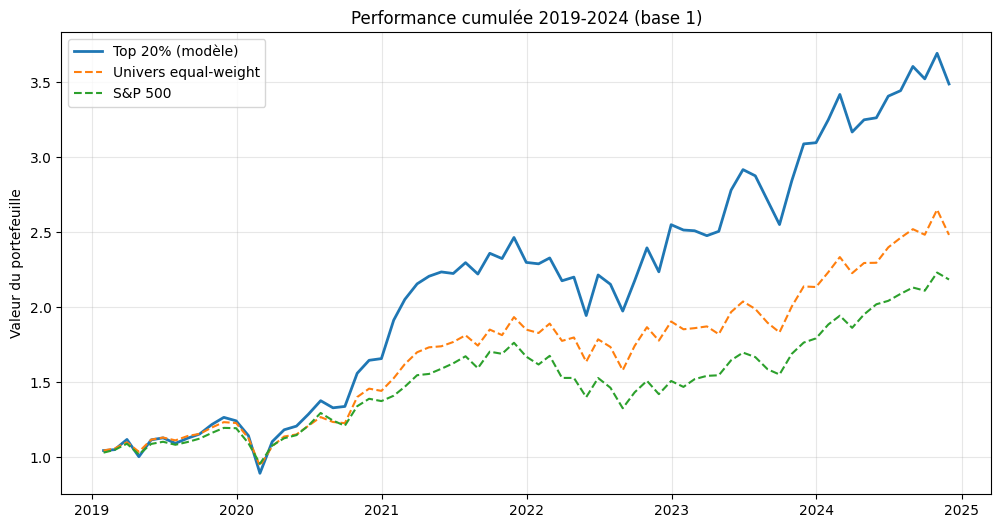

In [80]:
import matplotlib.pyplot as plt

# --- Benchmarks alignés (rendement du mois M+1, étiqueté à M) ---
# 1. Univers equal-weight = moyenne de TOUTES les actions notées ce mois
ew_bench = future_return.groupby(level="Date").mean()

# 2. S&P 500 (cap-weighted) : rendement de l'indice, décalé au futur
sp500_ret = features_df.groupby(level="Date")["SP500_return_1m"].first().shift(-1)

# --- Nettoyer / aligner (le dernier mois est NaN : pas de futur) ---
port_return = port_return.dropna()
ew_bench    = ew_bench.reindex(port_return.index)
sp500_ret   = sp500_ret.reindex(port_return.index)

# --- Sharpe annualisé (rf = 0) ---
def sharpe(r):
    return r.mean() / r.std() * np.sqrt(12)

print("Sharpe Top 20% (modèle) :", round(sharpe(port_return), 3))
print("Sharpe Univers EW       :", round(sharpe(ew_bench), 3))
print("Sharpe S&P 500          :", round(sharpe(sp500_ret), 3))
print()
print("Rendement annualisé Top 20% :", round((1+port_return.mean())**12 - 1, 4))
print("Rendement annualisé S&P 500 :", round((1+sp500_ret.mean())**12 - 1, 4))

# --- Performance cumulée ---
cum_port = (1 + port_return).cumprod()
cum_ew   = (1 + ew_bench).cumprod()
cum_sp   = (1 + sp500_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_port.index, cum_port, label="Top 20% (modèle)", linewidth=2)
plt.plot(cum_ew.index,   cum_ew,   label="Univers equal-weight", linestyle="--")
plt.plot(cum_sp.index,   cum_sp,   label="S&P 500", linestyle="--")
plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Performance cumulée 2019-2024 (base 1)")
plt.ylabel("Valeur du portefeuille")
plt.show()


In [81]:
## ===== Regression logistique CODEE A LA MAIN =====
## sigmoid, gradient_descent, predict : identiques a mon implementation d'origine
## cost et gradient : MEMES formules, reecrites en matriciel (vitesse sur ~28k lignes)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost_logistic_with_regularization(X, y, w, b, lambda_):
    m = X.shape[0]
    f_wb = sigmoid(X @ w + b)
    cost = -np.mean(y * np.log(f_wb) + (1 - y) * np.log(1 - f_wb))
    reg_cost = (lambda_ / (2 * m)) * np.sum(w**2)
    return cost + reg_cost

def compute_gradient_logistic_with_regularization(X, y, w, b, lambda_):
    m = X.shape[0]
    f_wb = sigmoid(X @ w + b)
    error = f_wb - y
    dj_dw = (X.T @ error) / m + (lambda_ / m) * w   # gradient + terme de regularisation L2
    dj_db = np.mean(error)
    return dj_dw, dj_db

def gradient_descent_logistic_with_regularization(X, y, w_in, b_in, alpha, lambda_, num_iters):
    w = w_in.copy()
    b = b_in
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_logistic_with_regularization(X, y, w, b, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 100 == 0:
            J_history.append(compute_cost_logistic_with_regularization(X, y, w, b, lambda_))
    return w, b, J_history

def predict(X, w, b):
    m = X.shape[0]
    y_pred = np.zeros((m,))
    for i in range(m):
        f_wb = sigmoid(np.dot(X[i], w) + b)
        y_pred[i] = 1 if f_wb >= 0.5 else 0
    return y_pred

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)   # probabilite continue (pour l'AUC et le backtest)


In [82]:
## ===== Walk-forward avec MA regression logistique (remplace sklearn) =====
results_maison = []
all_scores_maison = []

for i in range(len(folds)):
    fold = folds[i]
    train_mask = fold[0]
    test_mask  = fold[1]

    X_train, X_test, y_train, y_test = get_fold_data(
        X_scaled, y, train_mask, test_mask, normalize_macro=True)

    # DataFrame -> numpy
    X_tr, y_tr = X_train.values, y_train.values
    X_te, y_te = X_test.values,  y_test.values

    # Entrainement par descente de gradient (mon code)
    w0 = np.zeros(X_tr.shape[1])
    b0 = 0.0
    w_final, b_final, J_hist = gradient_descent_logistic_with_regularization(
        X_tr, y_tr, w0, b0, alpha=0.1, lambda_=0.01, num_iters=10000)

    # Predictions
    proba  = predict_proba(X_te, w_final, b_final)
    y_pred = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, proba)
    results_maison.append({"fold": i+1, "accuracy": acc, "f1": f1, "auc": auc})

    all_scores_maison.append(pd.Series(proba, index=X_test.index, name="score"))

scores_maison = pd.concat(all_scores_maison)

print("=== Regression logistique MAISON ===")
print(pd.DataFrame(results_maison))
print("AUC moyenne maison :", round(pd.DataFrame(results_maison)["auc"].mean(), 4))
print("(sklearn etait ~0.516 -> validation si proche)")


=== Regression logistique MAISON ===
   fold  accuracy        f1       auc
0     1  0.512018  0.439281  0.524160
1     2  0.529268  0.492801  0.534534
2     3  0.510886  0.483347  0.524642
3     4  0.512409  0.514222  0.516268
4     5  0.515017  0.532690  0.517736
5     6  0.486367  0.474755  0.479186
AUC moyenne maison : 0.5161
(sklearn etait ~0.516 -> validation si proche)


In [83]:
## ===== Alpha & Beta (regression CAPM) =====
## R_p = alpha + beta * R_marche + epsilon   (rf = 0)
from scipy.stats import linregress

def capm(port, bench, nom):
    res = linregress(bench, port)          # X = benchmark, Y = portefeuille
    beta    = res.slope
    alpha_m = res.intercept                # alpha mensuel
    t_alpha = alpha_m / res.intercept_stderr
    print(f"=== {nom} ===")
    print(f"Beta            : {beta:.3f}")
    print(f"Alpha mensuel   : {alpha_m:.5f}")
    print(f"Alpha annualise : {alpha_m*12:.4f}  ({alpha_m*12:.2%})")
    print(f"t-stat alpha    : {t_alpha:.2f}   (|t| > 2  => significatif a ~5%)")
    print(f"R2              : {res.rvalue**2:.3f}")
    print()

# 1. CAPM classique : vs le marche (S&P 500)
capm(port_return, sp500_ret, "vs S&P 500 (CAPM)")

# 2. Alpha du STOCK-PICKING pur : vs l'univers equal-weight
capm(port_return, ew_bench,  "vs Univers equal-weight (stock-picking pur)")


=== vs S&P 500 (CAPM) ===
Beta            : 1.328
Alpha mensuel   : 0.00397
Alpha annualise : 0.0477  (4.77%)
t-stat alpha    : 1.12   (|t| > 2  => significatif a ~5%)
R2              : 0.841

=== vs Univers equal-weight (stock-picking pur) ===
Beta            : 1.270
Alpha mensuel   : 0.00207
Alpha annualise : 0.0248  (2.48%)
t-stat alpha    : 0.83   (|t| > 2  => significatif a ~5%)
R2              : 0.922



In [84]:
## ===== Max Drawdown + Turnover + Couts de transaction (long-only) =====

# --- Max Drawdown : pire perte depuis un pic ---
cum = (1 + port_return).cumprod()
drawdown = (cum - cum.cummax()) / cum.cummax()
mdd = drawdown.min()
print(f"Max Drawdown (long-only) : {mdd:.2%}")

# --- Turnover mensuel : fraction du portefeuille renouvelee ---
selected = top_mask[top_mask]                       # ne garder que les True
sel_by_month = {d: set(s.index.get_level_values('Ticker'))
                for d, s in selected.groupby(level='Date')}
dates = sorted(sel_by_month.keys())
turnovers = [len(sel_by_month[dates[k]] - sel_by_month[dates[k-1]]) / len(sel_by_month[dates[k]])
             for k in range(1, len(dates))]
turnover_moyen = sum(turnovers) / len(turnovers)
print(f"Turnover mensuel moyen   : {turnover_moyen:.1%}")

# --- Impact des couts de transaction ---
cost_per_trade = 0.0010                              # 10 bps par trade (aller simple) - hypothese
cout_mensuel = turnover_moyen * 2 * cost_per_trade   # x2 : vente ancienne + achat nouvelle
port_return_net = port_return - cout_mensuel

print()
print(f"Cout mensuel estime      : {cout_mensuel:.3%}  (~{cout_mensuel*12:.2%}/an)")
print(f"Sharpe brut / net        : {sharpe(port_return):.3f}  /  {sharpe(port_return_net):.3f}")
print(f"Rdt annualise brut / net : {(1+port_return.mean())**12-1:.2%}  /  {(1+port_return_net.mean())**12-1:.2%}")


Max Drawdown (long-only) : -29.48%
Turnover mensuel moyen   : 42.7%

Cout mensuel estime      : 0.085%  (~1.03%/an)
Sharpe brut / net        : 0.973  /  0.932
Rdt annualise brut / net : 27.29%  /  26.02%


In [85]:
## ===== Portefeuille LONG-SHORT (market-neutral) =====
## Long le top 20%, short le bottom 20%  ->  beta ~ 0, isole le PUR alpha de selection

long_mask  = rangs >= 0.80   # top 20%
short_mask = rangs <= 0.20   # bottom 20%

long_ret  = future_return[long_mask].groupby(level='Date').mean()
short_ret = future_return[short_mask].groupby(level='Date').mean()

ls_return = (long_ret - short_ret).dropna()          # jambe longue - jambe courte

print(f"Rendement mensuel moyen L/S : {ls_return.mean():.3%}")
print(f"Rendement annualise L/S     : {(1+ls_return.mean())**12-1:.2%}")
print(f"Sharpe L/S                  : {sharpe(ls_return):.3f}")
print()

# Alpha / Beta du long-short vs marche (le beta doit etre proche de 0)
bench_ls = sp500_ret.reindex(ls_return.index)
ok = ls_return.notna() & bench_ls.notna()
capm(ls_return[ok], bench_ls[ok], "Long-Short vs S&P 500")


Rendement mensuel moyen L/S : 0.910%
Rendement annualise L/S     : 11.49%
Sharpe L/S                  : 0.698

=== Long-Short vs S&P 500 ===
Beta            : 0.529
Alpha mensuel   : 0.00259
Alpha annualise : 0.0311  (3.11%)
t-stat alpha    : 0.58   (|t| > 2  => significatif a ~5%)
R2              : 0.343

